In [1]:
from datetime import datetime

from matplotlib import pyplot as plt
from numpy import arange

from py_eddy_tracker import data
from py_eddy_tracker.dataset.grid import RegularGridDataset

import cartopy.crs as ccrs
import cartopy

import numpy as np

from glob import glob
import os

from py_eddy_tracker.observations.observation import EddiesObservations


# Params.:

In [2]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.


In [3]:
nyear = 2024

nmonth = 4

# Functions:

In [4]:
def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

In [5]:
def start_axes_map_subplots(title, nax): 
    """
    title = "xx ()"
    nax, e.g. 121
    """
    ax = plt.subplot(nax, projection=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND, facecolor=cartopy.feature.COLORS['land'], zorder=2) 

    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")

    # Add coastlines and grid lines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True);     
    gl.top_labels = False; gl.right_labels = False

    return ax

# Loading data:

In [6]:
from pathlib import Path as PathL

# Get the user's home directory
homedir = PathL.home()
# print(f"Home directory: {homedir}")



## MIOST:

In [7]:
indir_miost = str(homedir) + "/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
indir_miost_s = indir_miost + 'subset/'


In [8]:
data_paths_MIOST = sorted(glob(indir_miost_s + "dt_global_allsat_phy_l4_" + str(nyear) + str(nmonth).zfill(2) + "*_sub.nc"))

In [9]:
indir_eddies = str(homedir) + "/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/"

In [10]:
data_path  = data_paths_MIOST[19] # selecting day 20/04/24


In [11]:
a_names_MIOST = []
c_names_MIOST = []

for data_path in data_paths_MIOST:
   date = datetime(int(data_path[-15:-11]), int(data_path[-11:-9]),
                    int(data_path[-9:-7]))
   
   a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   
   a_names_MIOST.append(a_name)
   c_names_MIOST.append(c_name)

## Loading all eddies into same object:

In [12]:
all_a_MIOST = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in a_names_MIOST]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [13]:
all_c_MIOST = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in c_names_MIOST]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [14]:
all_a_MIOST

/opt/anaconda3/envs/venv_py-eddy-tracker_05/lib/python3.10/site-packages/py_eddy_tracker/observations/observation.py:302: RuntimeWarning: invalid value encountered in true_divide
  v /= hist_numba(x, bins=bins)[0]


| 600 observations from 27119.0 to 27148.0 (30.0 days, ~20 obs/day)
    |   Speed area      : 0.07 Mkm²/day
    |   Effective area  : 0.10 Mkm²/day
    ----Distribution in Amplitude:
    |   Amplitude bounds (cm)        0.00      1.00      2.00      3.00      4.00      5.00     10.00    500.00
    |   Percent of eddies         :      13.50     22.33     18.00      8.17      7.33      9.67     21.00
    ----Distribution in Radius:
    |   Speed radius (km)            0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       6.50     56.00     24.17      7.17      4.67      1.50      0.00      0.00
    |   Effective radius (km)        0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       5.33     44.50     24.00     14.50      3.33      8.33      0.00      0.00
    ----Distribution in Latitude
        Latitude bounds            -90.00    -60.00    -15.00     15.00     60.00     90.00
        Percent of eddies         :       0.00      0.00      0.00    100.00      0.00
        Percent of speed area     :       0.00      0.00      0.00    100.00      0.00
        Percent of effective area :       0.00      0.00      0.00    100.00      0.00
        Mean speed radius (km)    :        nan       nan       nan     30.07       nan
        Mean effective radius (km):        nan       nan       nan     36.40       nan
        Mean amplitude (cm)       :        nan       nan       nan      5.53       nan

In [15]:
all_c_MIOST

| 645 observations from 27119.0 to 27148.0 (30.0 days, ~22 obs/day)
    |   Speed area      : 0.05 Mkm²/day
    |   Effective area  : 0.06 Mkm²/day
    ----Distribution in Amplitude:
    |   Amplitude bounds (cm)        0.00      1.00      2.00      3.00      4.00      5.00     10.00    500.00
    |   Percent of eddies         :      24.03     31.16     20.47      8.37      4.34     10.54      1.09
    ----Distribution in Radius:
    |   Speed radius (km)            0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       6.98     68.99     17.83      5.27      0.78      0.16      0.00      0.00
    |   Effective radius (km)        0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       6.67     58.91     18.91     11.47      3.26      0.78      0.00      0.00
    ----Distribution in Latitude
        Latitude bounds            -90.00    -60.00    -15.00     15.00     60.00     90.00
        Percent of eddies         :       0.00      0.00      0.00    100.00      0.00
        Percent of speed area     :       0.00      0.00      0.00    100.00      0.00
        Percent of effective area :       0.00      0.00      0.00    100.00      0.00
        Mean speed radius (km)    :        nan       nan       nan     26.23       nan
        Mean effective radius (km):        nan       nan       nan     29.53       nan
        Mean amplitude (cm)       :        nan       nan       nan      2.52       nan

## Load DUACS-NRT:

In [16]:
indir_duacs_nrt = str(homedir) + "/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

data_paths_DUACS_NRT = sorted(glob(indir_duacs_nrt + "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_" + str(nyear) + str(nmonth).zfill(2) + "*_sub.nc"))


In [17]:
a_names_DUACS_NRT = []
c_names_DUACS_NRT = []

for data_path_DUACS_NRT in data_paths_DUACS_NRT:
   date = datetime(int(data_path_DUACS_NRT[-15:-11]), int(data_path_DUACS_NRT[-11:-9]),
                int(data_path_DUACS_NRT[-9:-7]))
   print(date)
   
   a_name_DUACS_NRT = indir_eddies + 'a_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   c_name_DUACS_NRT = indir_eddies + 'c_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   
   a_names_DUACS_NRT.append(a_name_DUACS_NRT)
   c_names_DUACS_NRT.append(c_name_DUACS_NRT)

2024-04-01 00:00:00
2024-04-02 00:00:00
2024-04-03 00:00:00
2024-04-04 00:00:00
2024-04-05 00:00:00
2024-04-06 00:00:00
2024-04-07 00:00:00
2024-04-08 00:00:00
2024-04-09 00:00:00
2024-04-10 00:00:00
2024-04-11 00:00:00
2024-04-12 00:00:00
2024-04-13 00:00:00
2024-04-14 00:00:00
2024-04-15 00:00:00
2024-04-16 00:00:00
2024-04-17 00:00:00
2024-04-18 00:00:00
2024-04-19 00:00:00
2024-04-20 00:00:00
2024-04-21 00:00:00
2024-04-22 00:00:00
2024-04-23 00:00:00
2024-04-24 00:00:00
2024-04-25 00:00:00
2024-04-26 00:00:00
2024-04-27 00:00:00
2024-04-28 00:00:00
2024-04-29 00:00:00
2024-04-30 00:00:00


## Loading all eddies into same object:

In [18]:

all_a_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in a_names_DUACS_NRT]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [19]:
all_c_DUACS_NRT = EddiesObservations.concatenate(
    [EddiesObservations.load_file(ff) for ff in c_names_DUACS_NRT]
)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [20]:
all_a_DUACS_NRT

| 427 observations from 27119.0 to 27148.0 (30.0 days, ~14 obs/day)
    |   Speed area      : 0.05 Mkm²/day
    |   Effective area  : 0.08 Mkm²/day
    ----Distribution in Amplitude:
    |   Amplitude bounds (cm)        0.00      1.00      2.00      3.00      4.00      5.00     10.00    500.00
    |   Percent of eddies         :      23.42     16.16     12.65      7.49      3.28     10.07     26.93
    ----Distribution in Radius:
    |   Speed radius (km)            0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       5.62     43.33     33.26     11.48      6.09      0.23      0.00      0.00
    |   Effective radius (km)        0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       5.39     36.53     25.06     15.22      8.43      9.37      0.00      0.00
    ----Distribution in Latitude
        Latitude bounds            -90.00    -60.00    -15.00     15.00     60.00     90.00
        Percent of eddies         :       0.00      0.00      0.00    100.00      0.00
        Percent of speed area     :       0.00      0.00      0.00    100.00      0.00
        Percent of effective area :       0.00      0.00      0.00    100.00      0.00
        Mean speed radius (km)    :        nan       nan       nan     32.91       nan
        Mean effective radius (km):        nan       nan       nan     39.02       nan
        Mean amplitude (cm)       :        nan       nan       nan      6.10       nan

In [21]:
all_c_DUACS_NRT

| 489 observations from 27119.0 to 27148.0 (30.0 days, ~16 obs/day)
    |   Speed area      : 0.05 Mkm²/day
    |   Effective area  : 0.06 Mkm²/day
    ----Distribution in Amplitude:
    |   Amplitude bounds (cm)        0.00      1.00      2.00      3.00      4.00      5.00     10.00    500.00
    |   Percent of eddies         :      33.95     21.06     15.13      9.41      7.36     10.02      3.07
    ----Distribution in Radius:
    |   Speed radius (km)            0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       7.77     47.85     31.08     12.07      1.02      0.00      0.20      0.00
    |   Effective radius (km)        0.00     15.00     30.00     45.00     60.00     75.00    100.00    200.00   2000.00
    |   Percent of eddies         :       7.16     45.19     25.77     16.16      2.45      3.07      0.20      0.00
    ----Distribution in Latitude
        Latitude bounds            -90.00    -60.00    -15.00     15.00     60.00     90.00
        Percent of eddies         :       0.00      0.00      0.00    100.00      0.00
        Percent of speed area     :       0.00      0.00      0.00    100.00      0.00
        Percent of effective area :       0.00      0.00      0.00    100.00      0.00
        Mean speed radius (km)    :        nan       nan       nan     29.42       nan
        Mean effective radius (km):        nan       nan       nan     32.70       nan
        Mean amplitude (cm)       :        nan       nan       nan      2.60       nan

# Plotting all eddies:

In [22]:
savefigs_dir = "figures/"

figname_root = "DUAC-OI_NRT_vs_MIOST-K_v2.0.1_eddy_id"

Saved figures/DUAC-OI_NRT_vs_MIOST-K_v2.0.1_eddy_id_202404new01.png


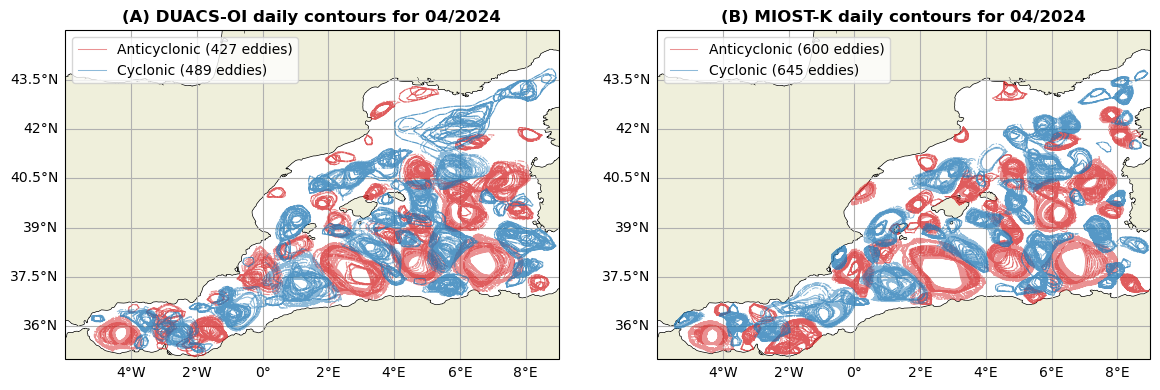

In [23]:
plt.figure(figsize=(14,5))
ax = start_axes_map_subplots("(A) DUACS-OI daily contours for "  + str(nmonth).zfill(2) + "/2024", 121) # NRT

ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

all_a_DUACS_NRT.display(ax, color="C3", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)
all_c_DUACS_NRT.display(ax, color="C0", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)

ax.legend(loc=2)
update_axes(ax)

ax = start_axes_map_subplots("(B) MIOST-K daily contours for "  + str(nmonth).zfill(2) + "/2024", 122) #  v2.0.1
ax.set_xlim(-6, 9), ax.set_ylim(35., 45.)

all_a_MIOST.display(ax, color="C3", linewidth=0.75, label="Anticyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)
all_c_MIOST.display(ax, color="C0", linewidth=0.75, label="Cyclonic ({nb_obs} eddies)", ref=-10, transform=ccrs.PlateCarree(), alpha=.5)

ax.legend(loc=2)
update_axes(ax)

# Save the figure
ndate = "2024" + str(nmonth).zfill(2)

output_filename = savefigs_dir + figname_root + f"_{ndate}new01.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")  
print(f"Saved {output_filename}")

plt.savefig("figures/fig2a-b.png", dpi=300, bbox_inches="tight")

plt.show()